# Analyse exploratoire des données d'infrastructure

L'objectif de ce notebook est d'explorer les données techniques
fournies avant de concevoir l'application d'analyse et de
recommandation.

Nous allons examiner la structure des données, les métriques
disponibles, leur évolution et les éventuelles anomalies.

1. Importation des librairies
2. Structure des données
3. Statistiques descriptives
4. Analyse des distributions
5. Analyse temporelle
6. Relations entre métriques
7. Identification des épisodes dégradés
8. Définition des seuils

## 1. Importation des librairies

In [52]:
import json
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')

## 2.  Structure des données

Nous chargeons le fichier de données afin de pouvoir effectuer
notre analyse exploratoire.

In [2]:
with open("../data/rapport.json" , "r") as f:
    data = json.load(f)

print (type(data))
print(len(data))

<class 'list'>
500


In [3]:
df = pd.DataFrame(data)

In [4]:
print (df.shape)

(500, 15)


Le jeu de données contient 500 observations et 15 variables. Chaque observation correspond à une mesure de l'infrastructure à un instant donné

## 3. Statistiques descriptives

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                500 non-null    object 
 1   cpu_usage                500 non-null    int64  
 2   memory_usage             500 non-null    int64  
 3   latency_ms               500 non-null    int64  
 4   disk_usage               500 non-null    int64  
 5   network_in_kbps          500 non-null    int64  
 6   network_out_kbps         500 non-null    int64  
 7   io_wait                  500 non-null    int64  
 8   thread_count             500 non-null    int64  
 9   active_connections       500 non-null    int64  
 10  error_rate               500 non-null    float64
 11  uptime_seconds           500 non-null    int64  
 12  temperature_celsius      500 non-null    int64  
 13  power_consumption_watts  500 non-null    int64  
 14  service_status           5

Le jeu de données contient 500 observations et 15 variables. Aucune valeur manquante n'est présente.    
La majorité des variables sont numériques et peuvent donc être analysées directement avec des statistiques descriptives. Les colonnes timestamp et service_status nécessiteront un traitement spécifique : la première pour l'analyse temporelle et la seconde pour l'analyse de l'état des services.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cpu_usage,500.0,60.66800,12.276122,52.00,54.00,56.00,59.00,99.00
memory_usage,500.0,67.62800,7.389101,62.00,63.00,66.00,67.00,92.00
latency_ms,500.0,156.01800,66.994733,113.00,124.00,132.00,139.00,384.00
disk_usage,500.0,63.90600,9.974776,57.00,59.00,60.00,62.00,97.00
network_in_kbps,500.0,1361.50800,431.733132,1080.00,1147.75,1221.00,1298.00,2854.00
network_out_kbps,500.0,1219.77400,316.454341,991.00,1050.00,1118.50,1185.25,2301.00
io_wait,500.0,4.01000,2.717475,2.00,3.00,3.00,3.00,14.00
thread_count,500.0,151.50400,7.270744,143.00,146.00,151.00,155.00,189.00
active_connections,500.0,58.86200,23.734228,48.00,49.00,50.00,52.00,136.00
error_rate,500.0,0.03158,0.030291,0.02,0.02,0.02,0.02,0.13


## 4. Analyse des distributions

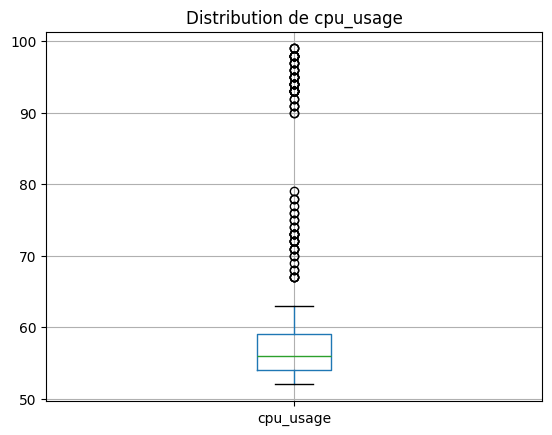

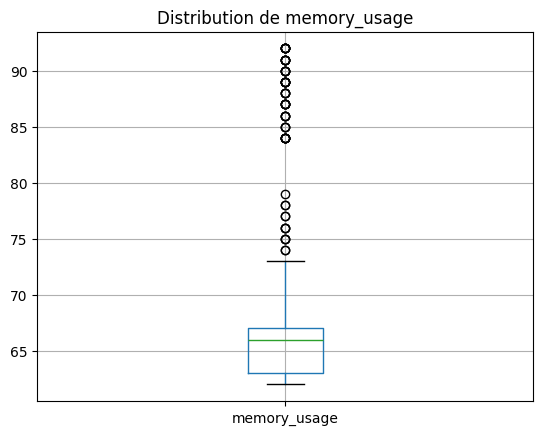

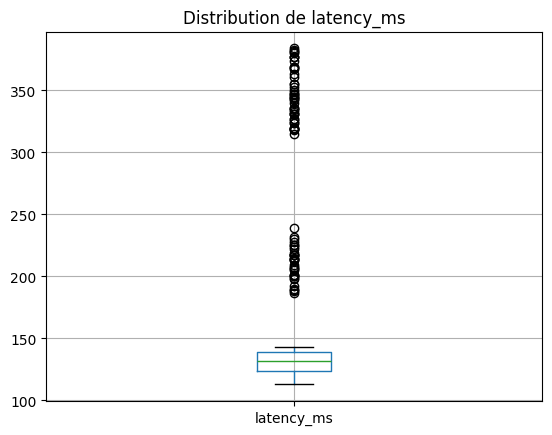

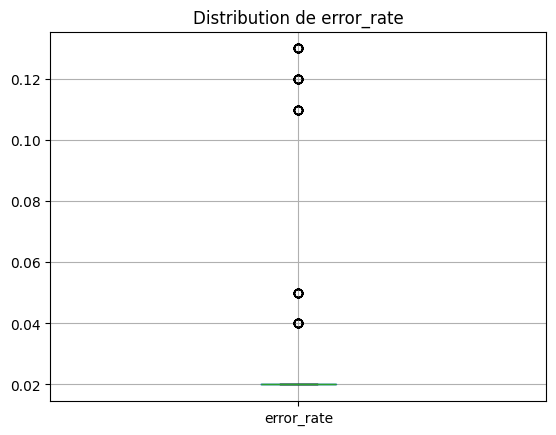

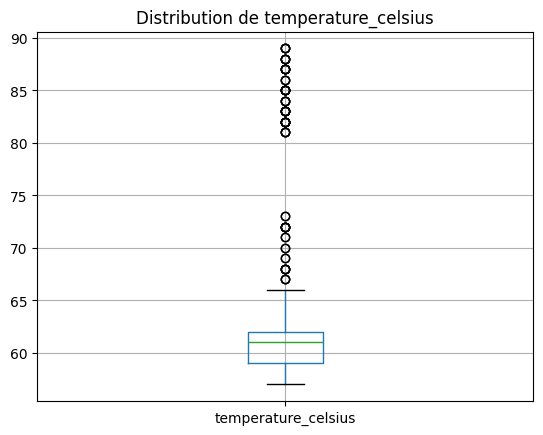

In [7]:
metrics = [
    "cpu_usage",
    "memory_usage",
    "latency_ms",
    "error_rate",
    "temperature_celsius",
]

for metric in metrics:
    df.boxplot(column=metric)
    plt.title(f"Distribution de {metric}")
    plt.show()

### Observation des distributions

Les boxplots mettent en évidence une séparation très nette entre la distribution principale et les valeurs maximales. Pour plusieurs métriques, les valeurs maximales sont complètement éloignées de la distribution principale, ce qui indique un changement important de comportement et pas simplement quelques variations autour de la distribution nominale.

On observe également que les valeurs extrêmes ne forment pas un seul groupe continu. Elles semblent se répartir en deux groupes distincts : un premier groupe situé dans un intervalle donné, puis un second groupe situé dans un intervalle significativement plus éloigné.

Cette structure suggère que les données pourraient présenter plusieurs régimes de fonctionnement :

- un régime nominal correspondant à la distribution principale ;
- un régime dégradé caractérisé par une forte augmentation simultanée de plusieurs métriques ;
- et potentiellement deux comportements distincts au sein de ce régime dégradé.

Cette hypothèse est particulièrement intéressante car les valeurs élevées semblent apparaître simultanément sur plusieurs métriques, notamment "cpu_usage", "memory_usage", "latency_ms", "error_rate",  "temperature_celsius".

## 5. Analyse temporelle

Étape 1 — préparer le temps

In [8]:
df['timestamp'] = pd.to_datetime( df['timestamp'])
df['timestamp'].head()

0   2023-10-01 12:00:00+00:00
1   2023-10-01 12:30:00+00:00
2   2023-10-01 13:00:00+00:00
3   2023-10-01 13:30:00+00:00
4   2023-10-01 14:00:00+00:00
Name: timestamp, dtype: datetime64[ns, UTC]

In [9]:
print ( "Début :", df.timestamp.min() )
print ( "Fin :", df.timestamp.max() )

Début : 2023-10-01 12:00:00+00:00
Fin : 2023-10-11 21:30:00+00:00


In [10]:
df.timestamp.diff().value_counts()

timestamp
0 days 00:30:00    499
Name: count, dtype: int64



Les observations sont espacées régulièrement de 30 minutes. Les 499 intervalles entre les 500 observations ont tous une durée de 30 minutes.

La série temporelle est donc continue sur la période étudiée, sans intervalle manquant. 

Étape 2 — Regarder les métriques dans le temps

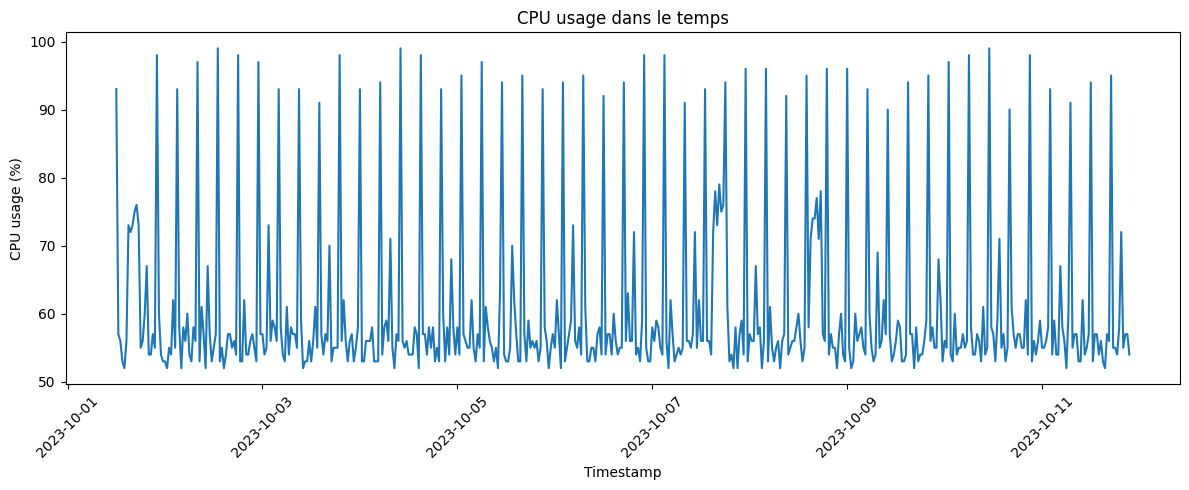

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["cpu_usage"])
plt.title("CPU usage dans le temps")
plt.xlabel("Timestamp")
plt.ylabel("CPU usage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

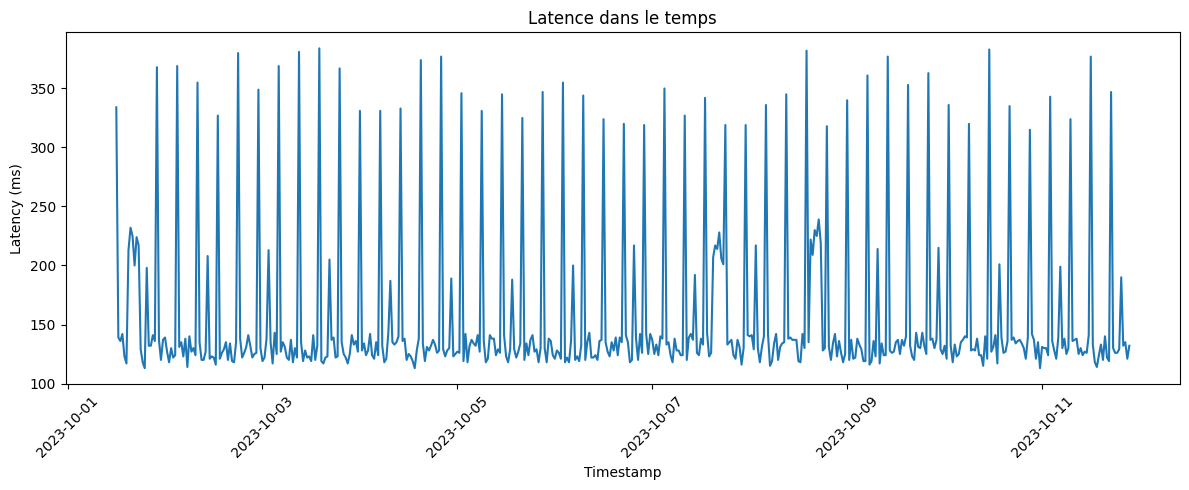

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["latency_ms"])
plt.title("Latence dans le temps")
plt.xlabel("Timestamp")
plt.ylabel("Latency (ms)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Analyse temporelle du CPU

La série temporelle confirme la séparation observée précédemment dans le boxplot.

La majorité des observations de "cpu_usage" se situe autour de 54–60 %, tandis que plusieurs pics atteignent 90–100 %. Ces pics sont donc très éloignés du régime nominal.

Les pics élevés ne semblent pas être des observations isolées : ils réapparaissent à plusieurs moments au cours de la période étudiée. De plus, les pics de "latency_ms" semblent se produire aux mêmes moments que les pics de "cpu_usage".

On observe donc un comportement temporel commun entre ces deux métriques. Cela renforce l'hypothèse d'un régime dégradé au cours duquel plusieurs métriques de l'infrastructure évoluent simultanément.

#### Plusieurs niveaux de dégradation

L'analyse temporelle fait apparaître plusieurs niveaux de comportement pour les principales métriques.

Pour "cpu_usage", on distingue un régime nominal autour de 54–60 %, des pics intermédiaires autour de 65–80 %, puis des pics extrêmes autour de 90–100 %.

Une structure similaire apparaît pour "latency_ms" : les valeurs nominales se situent principalement autour de 120–140 ms, avec un premier niveau autour de 190–200 ms et un niveau fortement dégradé autour de 320–380 ms.

Cette structure suggère que la dégradation de l'infrastructure ne se limite pas à un état binaire normal/anormal. Plusieurs niveaux de dégradation semblent présents.

## 6. Relations entre métriques

In [13]:
df[
    ["cpu_usage", "memory_usage", "latency_ms", "disk_usage",
     "error_rate", "temperature_celsius", "io_wait",
     "active_connections"]
].corr()["cpu_usage"].sort_values(ascending=False)

cpu_usage              1.000000
latency_ms             0.964589
error_rate             0.962527
active_connections     0.961843
disk_usage             0.959758
io_wait                0.950020
temperature_celsius    0.944317
memory_usage           0.939625
Name: cpu_usage, dtype: float64

Les métriques évoluent fortement ensemble sur cet échantillon.

In [14]:
df.groupby(
    df["cpu_usage"] >= 80
)[
    ["cpu_usage", "memory_usage", "latency_ms", "disk_usage",
     "error_rate", "temperature_celsius", "io_wait",
     "active_connections"]
].mean()

,cpu_usage,memory_usage,latency_ms,disk_usage,error_rate,temperature_celsius,io_wait,active_connections
cpu_usage,,,,,,,,
False,56.953437,65.388027,135.281596,60.866962,0.021863,60.638581,3.159645,51.192905
True,94.857143,88.244898,346.877551,91.877551,0.121020,84.755102,11.836735,129.448980


Comparer le comportement moyen de l'infrastructure lorsque le CPU est inférieur à 80 % et lorsqu'il est supérieur ou égal à 80 %. --> ceci nous a permis de constater que la dégradation ne concerne pas uniquement le CPU.

## 7. Identification des épisodes dégradés

In [20]:
degraded_mask = (
    (df["cpu_usage"] >= 80) &
    (df["latency_ms"] >= 300)
)

In [24]:
print("Nombre d'observations :", degraded_mask.sum())
print("Pourcentage :", degraded_mask.mean() * 100)

Nombre d'observations : 49
Pourcentage : 9.8


In [25]:
df.loc[
    degraded_mask,
    [
        "timestamp",
        "cpu_usage",
        "memory_usage",
        "latency_ms",
        "error_rate",
        "temperature_celsius",
        "disk_usage",
        "io_wait",
        "active_connections"
    ]
].head(10)

,timestamp,cpu_usage,memory_usage,latency_ms,error_rate,temperature_celsius,disk_usage,io_wait,active_connections
0,2023-10-01 12:00:00+00:00,93,86,334,0.12,84,89,12,126
20,2023-10-01 22:00:00+00:00,98,88,368,0.11,86,90,14,127
30,2023-10-02 03:00:00+00:00,93,87,369,0.12,88,88,13,129
40,2023-10-02 08:00:00+00:00,97,91,355,0.12,85,89,11,133
50,2023-10-02 13:00:00+00:00,99,92,327,0.12,87,92,10,136
60,2023-10-02 18:00:00+00:00,98,88,380,0.13,88,90,13,130
70,2023-10-02 23:00:00+00:00,97,84,349,0.12,83,89,10,130
80,2023-10-03 04:00:00+00:00,93,87,369,0.11,85,90,12,135
90,2023-10-03 09:00:00+00:00,93,92,381,0.11,88,92,11,129
100,2023-10-03 14:00:00+00:00,91,84,384,0.12,89,94,10,126


Les observations présentant simultanément une forte utilisation CPU et une latence élevée présentent également des niveaux élevés sur plusieurs autres métriques. Cela suggère l'existence d'un régime de fonctionnement dégradé dans les données étudiées.

## 8. Définition des seuils.  
8.1 — Identification des trois régimes

In [31]:
df["cpu_usage"].groupby(
    pd.cut(df["cpu_usage"], bins=range(50, 101, 5))
).size()

/var/folders/c1/vyhtdcy56rj1f2m39j9m8z9w0000gn/T/ipykernel_2773/741064782.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["cpu_usage"].groupby(


cpu_usage
(50, 55]     215
(55, 60]     179
(60, 65]      23
(65, 70]       9
(70, 75]      19
(75, 80]       6
(80, 85]       0
(85, 90]       2
(90, 95]      28
(95, 100]     19
Name: cpu_usage, dtype: int64

In [47]:
df["latency_ms"].groupby(
    pd.cut(df["latency_ms"], bins=range(100, 401, 20))
).size()

/var/folders/c1/vyhtdcy56rj1f2m39j9m8z9w0000gn/T/ipykernel_13004/3825776988.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["latency_ms"].groupby(


latency_ms
(100, 120]     69
(120, 140]    317
(140, 160]     31
(160, 180]      0
(180, 200]      9
(200, 220]     17
(220, 240]      8
(240, 260]      0
(260, 280]      0
(280, 300]      0
(300, 320]      7
(320, 340]     14
(340, 360]     13
(360, 380]     11
(380, 400]      4
Name: latency_ms, dtype: int64

In [32]:
cpu_distribution = (
    df["cpu_usage"]
    .groupby(
        pd.cut(df["cpu_usage"], bins=range(50, 101, 5))
    )
    .size()
    .reset_index(name="Nombre")
)

cpu_distribution

/var/folders/c1/vyhtdcy56rj1f2m39j9m8z9w0000gn/T/ipykernel_2773/3795635971.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["cpu_usage"]


,cpu_usage,Nombre
0,"(50, 55]",215
1,"(55, 60]",179
2,"(60, 65]",23
3,"(65, 70]",9
4,"(70, 75]",19
5,"(75, 80]",6
6,"(80, 85]",0
7,"(85, 90]",2
8,"(90, 95]",28
9,"(95, 100]",19


In [49]:
df["latency_ms"].groupby(
    pd.cut(
        df["latency_ms"],
        bins=range(100, 401, 10)
    )
).size()

/var/folders/c1/vyhtdcy56rj1f2m39j9m8z9w0000gn/T/ipykernel_13004/2705742053.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["latency_ms"].groupby(


latency_ms
(100, 110]      0
(110, 120]     69
(120, 130]    165
(130, 140]    152
(140, 150]     31
(150, 160]      0
(160, 170]      0
(170, 180]      0
(180, 190]      4
(190, 200]      5
(200, 210]      7
(210, 220]     10
(220, 230]      6
(230, 240]      2
(240, 250]      0
(250, 260]      0
(260, 270]      0
(270, 280]      0
(280, 290]      0
(290, 300]      0
(300, 310]      0
(310, 320]      7
(320, 330]      5
(330, 340]      9
(340, 350]     10
(350, 360]      3
(360, 370]      6
(370, 380]      5
(380, 390]      4
(390, 400]      0
Name: latency_ms, dtype: int64

In [50]:
df["cpu_range"] = pd.cut(
    df["cpu_usage"],
    bins=range(50, 101, 5)
)

df["latency_range"] = pd.cut(
    df["latency_ms"],
    bins=range(100, 401, 20)
)

pd.crosstab(
    df["cpu_range"],
    df["latency_range"]
)

latency_range,"(100, 120]","(120, 140]","(140, 160]","(180, 200]","(200, 220]","(220, 240]","(300, 320]","(320, 340]","(340, 360]","(360, 380]","(380, 400]"
cpu_range,,,,,,,,,,,
"(50, 55]",24,175,16,0,0,0,0,0,0,0,0
"(55, 60]",39,125,15,0,0,0,0,0,0,0,0
"(60, 65]",6,17,0,0,0,0,0,0,0,0,0
"(65, 70]",0,0,0,4,5,0,0,0,0,0,0
"(70, 75]",0,0,0,5,9,5,0,0,0,0,0
"(75, 80]",0,0,0,0,3,3,0,0,0,0,0
"(85, 90]",0,0,0,0,0,0,0,1,0,1,0
"(90, 95]",0,0,0,0,0,0,2,7,10,6,3
"(95, 100]",0,0,0,0,0,0,5,6,3,4,1


L'analyse conjointe de cpu_usage et latency_ms met en évidence trois zones de fonctionnement distinctes. Le régime normal est principalement caractérisé par un CPU compris approximativement entre 50 et 65 % et une latence comprise entre 110 et 150 ms. Un régime dégradé de niveau medium apparaît pour des valeurs de CPU et de latence intermédiaires, tandis qu'un régime fortement dégradé est caractérisé par un CPU supérieur à environ 85–90 % et une latence supérieure à environ 300 ms.

Les données mettent en évidence trois régimes distincts : normal, medium et high. Le CPU et la latence évoluent conjointement entre ces trois régimes.

In [53]:
conditions = [
    (df["cpu_usage"] <= 65) & (df["latency_ms"] <= 160),

    (df["cpu_usage"].between(65, 80)) &
    (df["latency_ms"].between(180, 240)),

    (df["cpu_usage"] >= 85) &
    (df["latency_ms"].between(310, 390))
]

labels = ["normal", "medium", "high"]

In [34]:
df["regime_temp"] = "autre"

df.loc[
    (df["cpu_usage"] <= 65) &
    (df["latency_ms"] <= 160),
    "regime_temp"
] = "normal"

df.loc[
    (df["cpu_usage"].between(65, 80)) &
    (df["latency_ms"].between(180, 240)),
    "regime_temp"
] = "medium"

df.loc[
    (df["cpu_usage"] >= 85) &
    (df["latency_ms"].between(310, 390)),
    "regime_temp"
] = "high"

In [35]:
df["regime_temp"].value_counts()

regime_temp
normal    417
high       49
medium     34
Name: count, dtype: int64

In [36]:
df.groupby("regime_temp")[metrics].mean()

,cpu_usage,memory_usage,latency_ms,error_rate,temperature_celsius
regime_temp,,,,,
high,94.857143,88.244898,346.877551,0.121020,84.755102
medium,72.264706,72.323529,210.617647,0.044706,67.941176
normal,55.705036,64.822542,129.139089,0.020000,60.043165


8.2 — Séparation entre les régimes

In [37]:
df.groupby("regime_temp")[metrics].agg(["min", "max"])

cpu_usage     memory_usage     latency_ms      error_rate        \
                  min max          min max        min  max        min   max   
regime_temp                                                                   
high               90  99           84  92        315  384       0.11  0.13   
medium             67  79           67  79        187  239       0.04  0.05   
normal             52  63           62  68        113  143       0.02  0.02   

            temperature_celsius      
                            min max  
regime_temp                          
high                         81  89  
medium                       62  73  
normal                       57  63

Observation des plages min/max

In [38]:
df.groupby("regime_temp")[["cpu_usage", "latency_ms"]].agg(["min", "max"])

cpu_usage     latency_ms     
                  min max        min  max
regime_temp                              
high               90  99        315  384
medium             67  79        187  239
normal             52  63        113  143

Les données montrent trois zones naturellement séparées. Nous pouvons maintenant chercher les seuils définitifs dans les espaces entre ces zones.

L'analyse conjointe de cpu_usage et latency_ms met en évidence trois zones distinctes dans les données : une zone normale, une zone de dégradation moyenne et une zone de dégradation forte. Des intervalles sans observations séparent ces zones. Ces intervalles sont utilisés comme base exploratoire pour définir les seuils du détecteur

8.3 — Choix des seuils

1- Régime Normal à Medium

- CPU normal max = 63.  
- CPU medium min = 67.  
- seuil intermédiaire : (63 + 67) / 2 = 65.  
- Latence normal max = 143.  
- Latence medium min = 187.  
- seuil intermédiaire : (143 + 187) / 2 = 165.  

2- Régime Medium à High

- CPU medium max = 79.  
- CPU high min = 90.  
- seuil intermédiaire : (79 + 90) / 2 = 84.5 = 85.    
- Latence medium max = 239.  
- Latence high min = 315.   
- seuil intermédiaire : (239 + 315) / 2 = 277.  

CPU et latence sont utilisées ensemble, car elles sont fortement corrélées et représentent les deux métriques principales de détection.

In [48]:
df["regime_detecte"] = "normal"

df.loc[
    (df["cpu_usage"] >= 65) &
    (df["latency_ms"] >= 165),
    "regime_detecte"
] = "medium"

df.loc[
    (df["cpu_usage"] >= 85) &
    (df["latency_ms"] >= 277),
    "regime_detecte"
] = "high"

Vérifier si les seuils choisis reproduisent exactement les trois régimes identifiés lors de l'exploration:

In [51]:
df["regime_temp"].value_counts() ==df["regime_detecte"].value_counts()

regime_temp
normal    True
high      True
medium    True
Name: count, dtype: bool

In [49]:
pd.crosstab(df["regime_temp"],df["regime_detecte"])

regime_detecte,high,medium,normal
regime_temp,,,
high,49,0,0
medium,0,34,0
normal,0,0,417


La comparaison entre regime_temp et regime_detecte montre une correspondance parfaite entre les deux classifications. Les seuils retenus permettent donc de distinguer les trois régimes observés dans le jeu de données : normal, medium et high.